In [1]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\ENVY\OneDrive\Desktop\projects\Product-Price-Optimizing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

xgb = joblib.load("xgboost_model.pkl")
feature_names = joblib.load("feature_columns.pkl")



In [3]:
df = pd.read_csv("laptop_data_cleaned.csv")

X = df.drop(columns=["Price"])
X = pd.get_dummies(X, drop_first=True)

# ensure feature order matches training
X = X[feature_names]  



In [4]:
# --- SHAP Explainer ---
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)



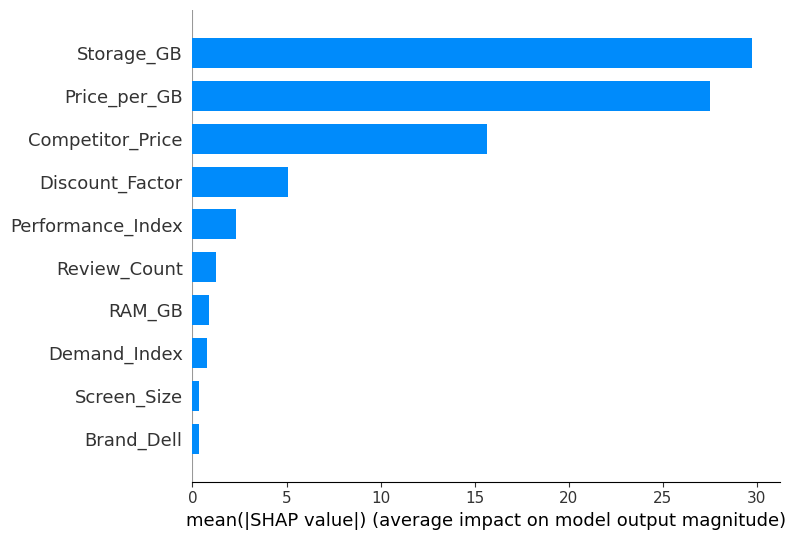

In [5]:
# --- Global Feature Importance (Bar Plot) ---
shap.summary_plot(shap_values, X, plot_type="bar", max_display=10)



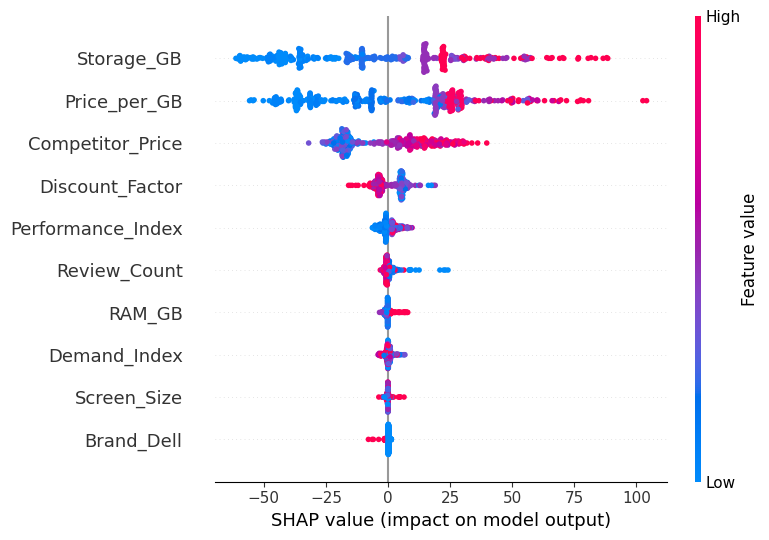

In [6]:

shap.summary_plot(shap_values, X, max_display=10)

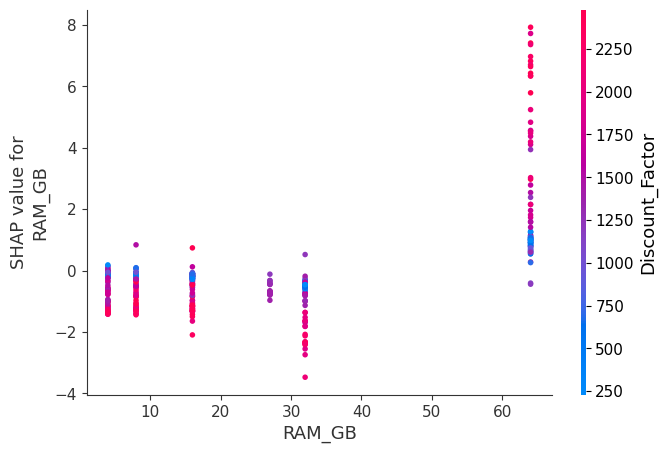

In [8]:
shap.dependence_plot("RAM_GB", shap_values, X)


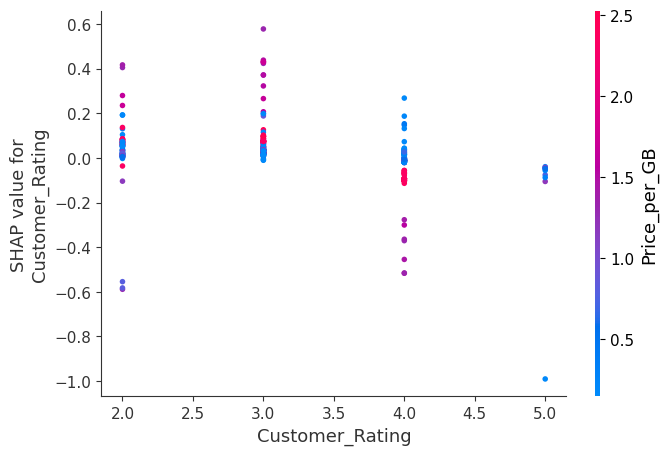

In [9]:
shap.dependence_plot("Customer_Rating", shap_values, X)

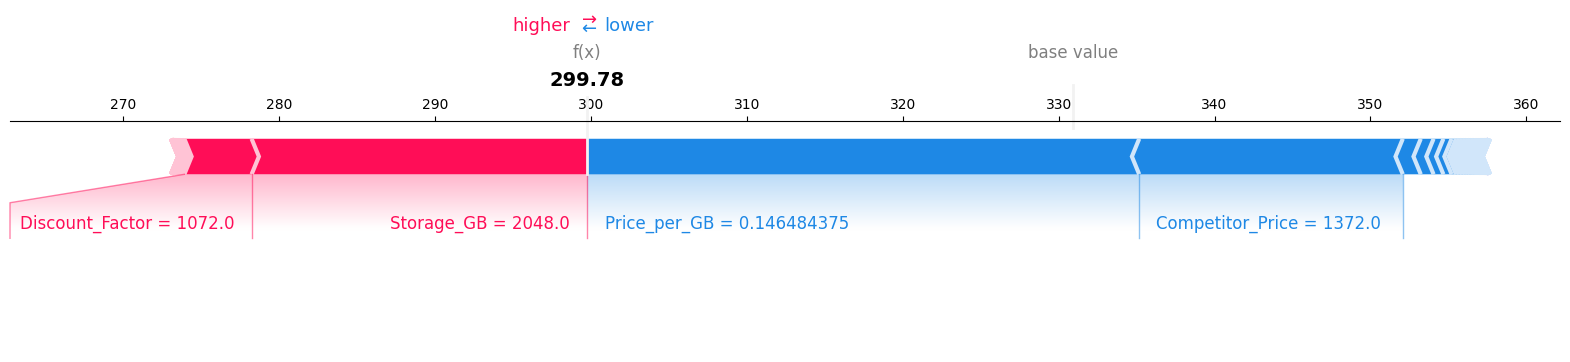

In [10]:
# Pick one row from dataset
row = X.iloc[0]

# Force plot for single prediction
shap.force_plot(
    explainer.expected_value, 
    shap_values[0,:], 
    X.iloc[0,:],
    matplotlib=True
)
plt.show()